### **Classical PINN for the 1D Viscous Burgers' Equation**

In [1]:
import os, json
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import burgers_common as bc

torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print("device:", DEVICE)
print(f"nu = {bc.NU:.6f},  x in [{bc.X_MIN},{bc.X_MAX}], t in [{bc.T_MIN},{bc.T_MAX}]")

device: cuda
nu = 0.003183,  x in [-1.0,1.0], t in [0.0,1.0]


In [ ]:
### NEW ONE ###

class ClassicalPINN(nn.Module):
    def __init__(self, hidden_layers=5, width=64, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(2, width), activation()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(width, width), activation()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)   # good default for tanh PINNs
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)


model = ClassicalPINN(hidden_layers=5, width=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("trainable parameters:", n_params)

In [4]:
class ClassicalPINN(nn.Module):
    def __init__(self, hidden_layers=4, width=8, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(2, width), activation()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(width, width), activation()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()
        
    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)   # good default for tanh PINNs
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)


model = ClassicalPINN(hidden_layers=4, width=8).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("trainable parameters:", n_params)

ClassicalPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=8, bias=True)
    (7): Tanh()
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)
trainable parameters: 249


In [5]:
# ---- cache collocation points ONCE ----
def build_batches(n_pde=4000, n_ic=400, n_bc=200, seed=0):
    x_f, t_f = bc.sample_interior(n_pde, DEVICE, seed=seed)
    x0, t0, u0 = bc.sample_ic(n_ic, DEVICE, seed=seed + 1)
    xb_pos, xb_neg, tb = bc.sample_bc(n_bc, DEVICE, seed=seed + 2)
    return dict(x_f=x_f, t_f=t_f, x0=x0, t0=t0, u0=u0,
                xb_pos=xb_pos, xb_neg=xb_neg, tb=tb)

W_PDE, W_IC, W_BC = 1.0, 10.0, 10.0   # up-weight the anchors

def composite_loss(model, B):
    r = bc.pde_residual(model, B["x_f"], B["t_f"])
    loss_pde = (r ** 2).mean()

    u0_pred = model(torch.cat([B["x0"], B["t0"]], dim=1))
    loss_ic = ((u0_pred - B["u0"]) ** 2).mean()

    loss_bc = (model(torch.cat([B["xb_pos"], B["tb"]], dim=1)) ** 2).mean() \
            + (model(torch.cat([B["xb_neg"], B["tb"]], dim=1)) ** 2).mean()

    total = W_PDE * loss_pde + W_IC * loss_ic + W_BC * loss_bc
    return total, {"pde": loss_pde.item(), "ic": loss_ic.item(), "bc": loss_bc.item()}

In [6]:
ADAM_EPOCHS = 8000
LBFGS_STEPS = 1500
LR = 2e-3

B = build_batches()
history = []

# ---- Phase 1: Adam + cosine annealing ----
opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ADAM_EPOCHS, eta_min=1e-5)

model.train()
for epoch in range(ADAM_EPOCHS):
    opt.zero_grad(set_to_none=True)
    loss, parts = composite_loss(model, B)
    loss.backward()
    opt.step(); sched.step()
    history.append(loss.item())
    if epoch % 400 == 0 or epoch == ADAM_EPOCHS - 1:
        print(f"[adam ] {epoch:5d} | loss {loss.item():.4e} | "
              f"pde {parts['pde']:.2e} ic {parts['ic']:.2e} bc {parts['bc']:.2e} "
              f"| lr {sched.get_last_lr()[0]:.1e}")

# ---- Phase 2: L-BFGS polish ----
opt_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=1.0, max_iter=LBFGS_STEPS,
    history_size=50, tolerance_grad=1e-9, tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

def closure():
    opt_lbfgs.zero_grad(set_to_none=True)
    loss, _ = composite_loss(model, B)
    loss.backward()
    history.append(loss.item())
    return loss

print("[lbfgs] polishing ...")
opt_lbfgs.step(closure)
final_loss, parts = composite_loss(model, B)
print(f"[lbfgs] done | loss {final_loss.item():.4e} | "
      f"pde {parts['pde']:.2e} ic {parts['ic']:.2e} bc {parts['bc']:.2e}")

/dolfinx-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[adam ]     0 | loss 9.4180e+00 | pde 3.90e-01 ic 6.43e-01 bc 2.60e-01 | lr 2.0e-03
[adam ]   400 | loss 3.9369e-01 | pde 2.78e-01 ic 9.34e-03 bc 2.18e-03 | lr 2.0e-03
[adam ]   800 | loss 2.7787e-01 | pde 2.28e-01 ic 4.45e-03 bc 5.18e-04 | lr 2.0e-03
[adam ]  1200 | loss 2.4154e-01 | pde 2.04e-01 ic 3.59e-03 bc 2.01e-04 | lr 1.9e-03
[adam ]  1600 | loss 2.2614e-01 | pde 1.92e-01 ic 3.24e-03 bc 1.39e-04 | lr 1.8e-03
[adam ]  2000 | loss 2.1483e-01 | pde 1.84e-01 ic 3.00e-03 bc 1.25e-04 | lr 1.7e-03
[adam ]  2400 | loss 2.0616e-01 | pde 1.76e-01 ic 2.88e-03 bc 1.01e-04 | lr 1.6e-03
[adam ]  2800 | loss 1.9606e-01 | pde 1.69e-01 ic 2.59e-03 bc 8.82e-05 | lr 1.5e-03
[adam ]  3200 | loss 1.7682e-01 | pde 1.53e-01 ic 2.35e-03 bc 5.50e-05 | lr 1.3e-03
[adam ]  3600 | loss 1.5166e-01 | pde 1.31e-01 ic 2.02e-03 bc 4.68e-05 | lr 1.2e-03
[adam ]  4000 | loss 1.1944e-01 | pde 1.03e-01 ic 1.58e-03 bc 6.94e-05 | lr 1.0e-03
[adam ]  4400 | loss 8.0416e-02 | pde 6.86e-02 ic 1.11e-03 bc 7.68e-05 | lr 

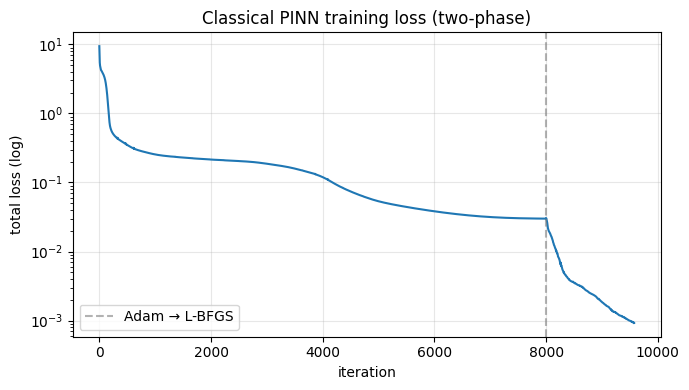

Relative L2 error by snapshot:
  t=0.25 -> 1.4548e-02
  t=0.50 -> 4.8383e-02
  t=0.75 -> 1.1491e-01
  t=0.99 -> 1.5680e-01
mean relative L2: 8.3661e-02


In [8]:
plt.figure(figsize=(7, 4))
plt.semilogy(history)
plt.axvline(ADAM_EPOCHS, color="grey", ls="--", alpha=0.6, label="Adam → L-BFGS")
plt.xlabel("iteration"); plt.ylabel("total loss (log)")
plt.title("Classical PINN training loss (two-phase)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
loss_fig = plt.gcf()
plt.show()

T_SNAPSHOTS = [0.25, 0.50, 0.75, 0.99]
results = bc.evaluate_on_grid(model, T_SNAPSHOTS, nx=256, device=DEVICE)
print("Relative L2 error by snapshot:")
for t, (_, _, _, l2) in results.items():
    print(f"  t={t:.2f} -> {l2:.4e}")
mean_l2 = float(np.mean([v[3] for v in results.values()]))
print(f"mean relative L2: {mean_l2:.4e}")

In [9]:
def save_classical_run(model, history, results, mean_l2, loss_fig,
                       tag="classical_pinn", ckpt_dir=CKPT_DIR):
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base = f"{tag}_{stamp}"
    paths = {}

    ckpt = {
        "state_dict": model.state_dict(),
        "arch": {"hidden_layers": 5, "width": 64, "activation": "Tanh"},
        "in_dim": 2, "out_dim": 1,
    }
    paths["model"] = os.path.join(ckpt_dir, base + ".pt")
    torch.save(ckpt, paths["model"])

    paths["hist"] = os.path.join(ckpt_dir, base + "_hist.npy")
    np.save(paths["hist"], np.asarray(history, dtype=np.float32))

    paths["loss_fig"] = os.path.join(ckpt_dir, base + "_loss.png")
    loss_fig.savefig(paths["loss_fig"], dpi=150, bbox_inches="tight")

    meta = {
        "tag": tag, "timestamp": stamp, "final_loss": float(history[-1]),
        "mean_rel_l2": mean_l2,
        "per_t_rel_l2": {str(t): float(results[t][3]) for t in results},
        "seed": 0, "device": str(DEVICE), "nu": float(bc.NU),
        "torch": torch.__version__,
    }
    paths["meta"] = os.path.join(ckpt_dir, base + "_meta.json")
    with open(paths["meta"], "w") as fh:
        json.dump(meta, fh, indent=2)

    print(f"saved run '{base}':")
    for k, v in paths.items():
        print(f"  {k:9s} -> {v}")
    return paths, base

paths, base = save_classical_run(model, history, results, mean_l2, loss_fig)

saved run 'classical_pinn_20260715_103914':
  model     -> checkpoints/classical_pinn_20260715_103914.pt
  hist      -> checkpoints/classical_pinn_20260715_103914_hist.npy
  loss_fig  -> checkpoints/classical_pinn_20260715_103914_loss.png
  meta      -> checkpoints/classical_pinn_20260715_103914_meta.json


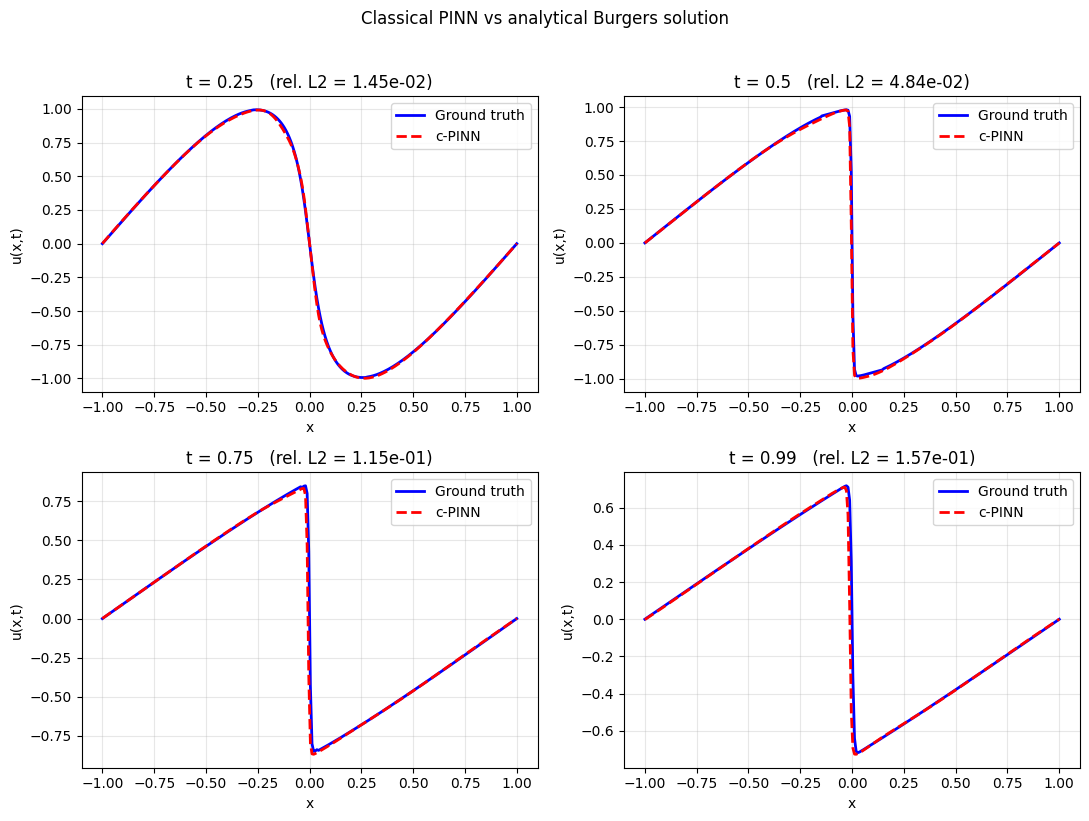

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, t in zip(axes.ravel(), T_SNAPSHOTS):
    x_grid, u_pred, u_exact, l2 = results[t]
    ax.plot(x_grid, u_exact, "b-", lw=2, label="Ground truth")
    ax.plot(x_grid, u_pred, "r--", lw=2, label="c-PINN")
    ax.set_title(f"t = {t}   (rel. L2 = {l2:.2e})")
    ax.set_xlabel("x"); ax.set_ylabel("u(x,t)")
    ax.grid(True, alpha=0.3); ax.legend()
fig.suptitle("Classical PINN vs analytical Burgers solution", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DIR, base + "_pred_vs_exact.png"), dpi=150, bbox_inches="tight")
plt.show()

### **Quantum vs Classical vs Ground Truth**

In [12]:
import os, glob, json
import pennylane as qml


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_DIR = "checkpoints"

# ---- Force the re-uploading flag to match how the sweep models were TRAINED.
# Your train_qapinn(...) used the default reupload=False for the sweep runs,
# so set this to False even if the checkpoint dict says otherwise.
FORCE_REUPLOAD = False   # set None to trust each checkpoint's own flag


# ============================================================
# Circuit + QAPINN — must match training definitions exactly
# ============================================================
def make_quantum_layer(n_qubits, n_layers=8, reupload=False):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
        for l in range(n_layers):
            if reupload and l > 0:
                qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
            for w in range(n_qubits):
                qml.RX(weights[l, w], wires=w)
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qml.CNOT(wires=[i, j])
        return qml.probs(wires=range(n_qubits))
    return circuit


class QAPINN(nn.Module):
    def __init__(self, n_qubits, hidden=8, n_layers=8, reupload=False):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.qnode = make_quantum_layer(n_qubits, n_layers, reupload=reupload)
        self.q_weights = nn.Parameter(torch.empty(n_layers, n_qubits))
        nn.init.uniform_(self.q_weights, -np.pi, np.pi)
        self.head = nn.Sequential(
            nn.Linear(2 ** n_qubits, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, X):
        dev = X.device
        q_out = self.qnode(X.cpu(), self.q_weights.cpu())
        return self.head(q_out.to(dev, dtype=X.dtype))




class ClassicalPINN(nn.Module):
    def __init__(self, hidden_layers=4, width=8, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(2, width), activation()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(width, width), activation()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()
        
    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)   # good default for tanh PINNs
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)
    
# ============================================================
# Loaders
# ============================================================
def latest(pattern):
    files = sorted(glob.glob(os.path.join(CKPT_DIR, pattern)))
    return files[-1] if files else None


def load_classical(path, device=DEVICE):
    ck = torch.load(path, map_location=device)
    a = ck.get("arch", {"hidden_layers": 4, "width": 8})
    m = ClassicalPINN(a["hidden_layers"], a["width"]).to(device)
    m.load_state_dict(ck["state_dict"]); m.eval()
    return m


def load_qapinn(path, device=DEVICE):
    ck = torch.load(path, map_location=device)
    reup = ck.get("reupload", False) if FORCE_REUPLOAD is None else FORCE_REUPLOAD
    m = QAPINN(
        ck["n_qubits"],
        hidden=ck.get("hidden", 8),
        n_layers=ck.get("n_layers") or 8,
        reupload=reup,
    ).to(device)
    m.load_state_dict(ck["state_dict"]); m.eval()
    return m


# ============================================================
# Gather models  (label -> (model, plot style))
# ============================================================
models = {}

cpath = latest("classical_pinn_*.pt")
if cpath:
    models["Classical PINN"] = (load_classical(cpath), dict(color="#2CA02C", ls="--", lw=2))
    print("loaded classical:", os.path.basename(cpath))

qcolors = {3: "#4C72B0", 4: "#C44E52", 5: "#8172B3"}
for n in (3, 4, 5):
    qp = latest(f"qapinn_sweep_{n}q_*.pt")
    if qp:
        models[f"QA-PINN {n}q"] = (load_qapinn(qp), dict(color=qcolors[n], ls=":", lw=1.8))
        print(f"loaded QA-PINN {n}q:", os.path.basename(qp))

print("\nmodels in comparison:", list(models.keys()))

RuntimeError: Error(s) in loading state_dict for ClassicalPINN:
	Missing key(s) in state_dict: "net.10.weight", "net.10.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([8, 2]) from checkpoint, the shape in current model is torch.Size([64, 2]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for net.2.weight: copying a param with shape torch.Size([8, 8]) from checkpoint, the shape in current model is torch.Size([64, 64]).
	size mismatch for net.2.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for net.4.weight: copying a param with shape torch.Size([8, 8]) from checkpoint, the shape in current model is torch.Size([64, 64]).
	size mismatch for net.4.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismat